
# Árvore de Decisão: C4.5 vs. Ensemble (Gradient Boosting) na Concessão de Crédito

**Disciplina:** Inteligência Computacional — CESUPA, Engenharia de Computação (EC8MA)
**Modalidade:** 4. Árvore de decisão
**Autores:** Gustavo Teixeira Bittencourt de Oliveira, Edgar Klewert, Christophe Abelem, Adler Castro

## Contexto

Este notebook aplica árvores de decisão a um problema de **concessão de crédito**: dado o
histórico e a situação financeira de um cliente, prever se ele será um **bom pagador** ou um
**mau pagador**. É um problema real do setor financeiro, com uma tensão clássica entre dois
tipos de erro: recusar crédito a quem pagaria (custo baixo) e aprovar crédito a quem não vai
pagar (custo alto).

Comparamos duas estratégias, como pede o enunciado:

1. **C4.5** (árvore única, com razão de ganho) — biblioteca `chefboost`.
2. **Gradient Boosting** (ensemble de árvores) — `scikit-learn`.

Como referência adicional, também treinamos um **CART com critério de entropia** do
`scikit-learn` — ele **não é C4.5** (divisões sempre binárias, sem razão de ganho, poda por
complexidade de custo diferente), mas é o que o `scikit-learn` de fato implementa quando se
usa `DecisionTreeClassifier(criterion="entropy")`, e é nele que baseamos a **busca da árvore
mais enxuta**, porque a biblioteca do C4.5 usada aqui não tem os controles de complexidade
necessários para essa busca (ver `docs/DECISOES.md`, itens 1 e 4).

Todas as decisões técnicas deste notebook — e por que tomamos cada uma — estão registradas em
`docs/DECISOES.md`. 


In [ ]:

# Em Google Colab, descomente a linha abaixo para instalar as dependências:
# !pip install -q -r ../requirements.txt

import sys
from pathlib import Path

CAMINHO_PROJETO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(CAMINHO_PROJETO) not in sys.path:
    sys.path.insert(0, str(CAMINHO_PROJETO))

import pandas as pd
import matplotlib.pyplot as plt

from src.arvore import config
from src.arvore import metricas_divisao as md_metricas
from src.arvore.dados import (
    carregar_dataset_bruto,
    checar_dataset,
    preparar_para_c45,
    preparar_para_cart,
    dividir_treino_teste,
)
from src.arvore.c45 import treinar_c45, avaliar_c45
from src.arvore.busca_enxuta import buscar_arvore_enxuta_cart, buscar_arvore_enxuta_c45
from src.arvore.ensemble import treinar_gradient_boosting, importancia_das_variaveis
from src.arvore.avaliacao import (
    baseline_classe_majoritaria,
    baseline_um_corte,
    matriz_de_confusao_legivel,
    taxa_de_erro_por_tipo,
    experimento_estabilidade_cart,
    selecionar_exemplos,
)
from src.arvore.regras import (
    extrair_regras_cart,
    formatar_regra,
    extrair_regras_c45,
    formatar_regra_c45,
    caminho_decisao_cart,
    traduzir_classe,
)
from src.arvore.visualizacao import (
    desenhar_arvore_cart,
    grafico_complexidade_vs_acuracia,
    tabela_candidatos_cart,
    salvar_figura,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

pd.set_option("display.max_columns", 30)
print("Semente principal:", config.SEMENTE_PRINCIPAL)
print("Meta de acurácia:", f"{config.META_ACURACIA:.0%}")


Semente principal: 42
Meta de acurácia: 71%



## Dataset: German Credit (`credit-g`, OpenML)

Não assumimos nada sobre o dataset — conferimos abaixo através de uma análise exploratória de dados como o enunciado pede: número de
linhas, atributos, tipos, valores faltantes e proporção das classes.


In [2]:

df = carregar_dataset_bruto()
checagem = checar_dataset(df)

print(f"Linhas: {checagem.n_linhas}")
print(f"Colunas (incluindo alvo): {checagem.n_colunas}")
print(f"Atributos categóricos ({len(checagem.colunas_categoricas)}): {checagem.colunas_categoricas}")
print(f"Atributos numéricos ({len(checagem.colunas_numericas)}): {checagem.colunas_numericas}")
print(f"Valores faltantes: {checagem.n_valores_faltantes}")
print("Proporção de classes:")
print(checagem.proporcao_classes)

df.head()


Linhas: 1000
Colunas (incluindo alvo): 21
Atributos categóricos (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Atributos numéricos (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Valores faltantes: 0
Proporção de classes:
class
good    0.7
bad     0.3
Name: proportion, dtype: float64


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad



Confirmado: **1000 linhas**, **20 atributos** (13 categóricos + 7 numéricos) + a classe alvo,
**sem valores faltantes**, e proporção de classes **70% bom pagador / 30% mau pagador** — como
esperado para este dataset, e moderado o suficiente para que a meta de acurácia não seja
trivial (diferente do dataset de fraude que descartamos — ver `docs/DECISOES.md`, item 0).



## Como as divisões são escolhidas: entropia, ganho e razão de ganho, passo a passo

O C4.5 escolhe, em cada nó, o atributo com **maior razão de ganho** (*gain ratio*) — não o
maior ganho de informação puro, porque o ganho puro favorece atributos com muitos valores
distintos (no limite, um identificador único), mesmo que eles não generalizem para dados
novos (ver `tests/test_metricas_divisao.py`, teste do atributo tipo ID).

Calculamos abaixo, com nossas próprias funções (`src/arvore/metricas_divisao.py`, testadas
contra o exemplo clássico Play Tennis), a entropia inicial e a razão de ganho de cada atributo
**no primeiro nó da árvore real** (conjunto de treino completo do German Credit), para mostrar
que o atributo escolhido pelo C4.5 de fato tem a maior razão de ganho.


In [3]:

treino_df, teste_df = dividir_treino_teste(df, config.COLUNA_ALVO)
df_c45 = preparar_para_c45(df)
treino_c45 = df_c45.loc[treino_df.index]
teste_c45 = df_c45.loc[teste_df.index]

entropia_inicial = md_metricas.entropia(treino_c45["Decision"])
print(f"Entropia inicial do conjunto de treino: {entropia_inicial:.4f}")

atributos = [c for c in treino_c45.columns if c != "Decision"]
ranking = md_metricas.melhor_atributo_por_razao_de_ganho(treino_c45, atributos, "Decision")

tabela_ranking = pd.DataFrame(ranking).T.rename_axis("atributo").reset_index()
tabela_ranking.columns = ["atributo", "ganho_informacao", "split_information", "razao_de_ganho"]
tabela_ranking.round(4).head(10)


Entropia inicial do conjunto de treino: 0.8813


,atributo,ganho_informacao,split_information,razao_de_ganho
0,credit_amount,0.8344,9.5220,0.0876
1,checking_status,0.0953,1.7969,0.0530
2,foreign_worker,0.0056,0.2189,0.0254
3,credit_history,0.0407,1.6761,0.0243
4,duration,0.0648,3.7898,0.0171
5,other_parties,0.0090,0.5530,0.0163
6,savings_status,0.0272,1.6867,0.0161
7,purpose,0.0416,2.6512,0.0157
8,other_payment_plans,0.0106,0.8385,0.0126
9,age,0.0516,5.2422,0.0098


In [4]:

melhor_atributo = tabela_ranking.iloc[0]["atributo"]
print(f"Atributo com maior razão de ganho: {melhor_atributo}")

arvore_c45_raiz = treinar_c45(treino_c45, profundidade_maxima=1)
primeira_linha_regra = next(
    linha for linha in arvore_c45_raiz.texto_das_regras().splitlines() if '"feature"' in linha
)
print("Atributo que a chefboost realmente escolheu na raiz:", primeira_linha_regra.strip())


Atributo com maior razão de ganho: credit_amount


Atributo que a chefboost realmente escolheu na raiz: # {"feature": "credit_amount", "instances": 800, "metric_value": 0.8813, "depth": 1}



**Confirmado:** o atributo do maior razão de ganho no nosso cálculo manual é o mesmo que a
chefboost escolheu como raiz da árvore C4.5. Isso demonstra, com números reais deste dataset
(não só com Play Tennis), que a lógica de seleção de divisões do C4.5 está correta em ambas as
implementações — a nossa (`metricas_divisao.py`) e a da biblioteca.



## Meta de acurácia (definida antes da busca de hiperparâmetros)

Antes de rodar qualquer busca, medimos duas linhas de base:


In [5]:

df_cart = preparar_para_cart(df)
treino_cart = df_cart.loc[treino_df.index]
teste_cart = df_cart.loc[teste_df.index]

x_treino, y_treino = treino_cart.drop(columns=[config.COLUNA_ALVO]), treino_cart[config.COLUNA_ALVO]
x_teste, y_teste = teste_cart.drop(columns=[config.COLUNA_ALVO]), teste_cart[config.COLUNA_ALVO]

baseline_majoritaria = baseline_classe_majoritaria(y_treino)
baseline_1_corte = baseline_um_corte(x_treino, y_treino)

print(f"Baseline (classe majoritária):         {baseline_majoritaria:.1%}")
print(f"Baseline (árvore de profundidade 1, CV): {baseline_1_corte:.1%}")
print(f"Meta de acurácia definida:               {config.META_ACURACIA:.1%}")


Baseline (classe majoritária):         70.0%
Baseline (árvore de profundidade 1, CV): 70.0%
Meta de acurácia definida:               71.0%



A meta de **71%** foi definida acima das duas baselines (70%), mas dentro do teto que uma
árvore rasa consegue de fato entregar neste dataset — uma checagem exploratória mostrou que
nem mesmo variando profundidade e mínimo de amostras por folha um CART supera ~72% de acurácia
de validação cruzada aqui. O raciocínio completo está em `docs/DECISOES.md`, item 2.



## Busca da árvore mais enxuta (CART)

Variamos profundidade máxima e mínimo de amostras por folha, medindo a acurácia média de
**validação cruzada só no treino** (nunca olhando o teste nesta etapa — ver `docs/DECISOES.md`,
item 3, sobre por que isso importa). Entre as configurações que atingem a meta, escolhemos a de
**menor número de folhas** e, em empate, **menor profundidade**.


In [6]:

melhor_cart, candidatos_cart = buscar_arvore_enxuta_cart(x_treino, y_treino)
print("Melhor candidato:", melhor_cart)

tabela_cart_completa = tabela_candidatos_cart(candidatos_cart)
tabela_cart_completa.to_csv(config.DIR_RESULTADOS_TABELAS / "busca_enxuta_cart.csv", index=False)
tabela_cart_completa.head(15)


Melhor candidato: CandidatoArvore(profundidade_maxima=3, min_amostras_folha=1, acuracia_cv=np.float64(0.71875), n_folhas=np.int64(8), profundidade_real=3, atinge_meta=np.True_)


,profundidade_maxima,min_amostras_folha,n_folhas,profundidade_real,acuracia_cv,atinge_meta
10,3.0,1,8,3,0.7188,True
11,3.0,5,8,3,0.7162,True
13,3.0,20,8,3,0.7100,True
18,4.0,20,13,4,0.7200,True
24,5.0,40,13,5,0.7100,True
29,6.0,40,14,6,0.7100,True
15,4.0,1,15,4,0.7100,True
16,4.0,5,15,4,0.7162,True
23,5.0,20,17,5,0.7137,True
28,6.0,20,20,6,0.7100,True


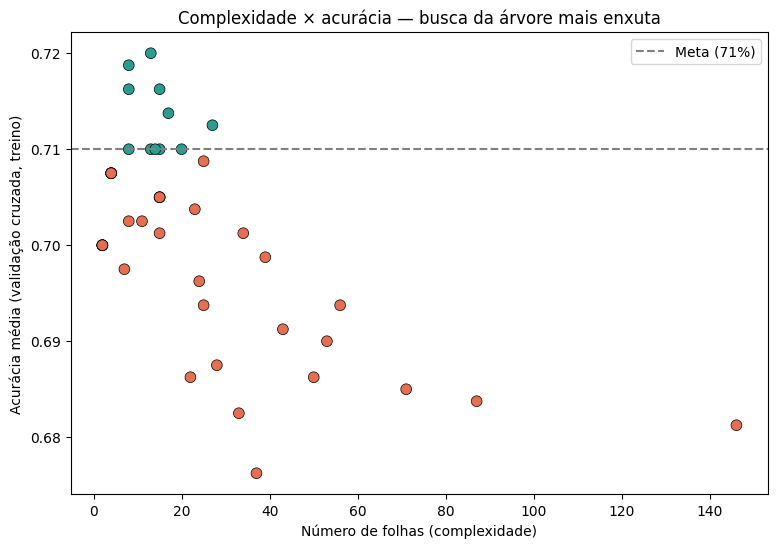

In [7]:

fig = grafico_complexidade_vs_acuracia(candidatos_cart)
salvar_figura(fig, "complexidade_vs_acuracia_cart.png")
plt.show()



## Árvore final (CART) e suas regras

Treinamos a configuração escolhida no treino completo e avaliamos no teste **uma única vez**.


Acurácia no teste (CART, 8 folhas, profundidade 3): 70.5%


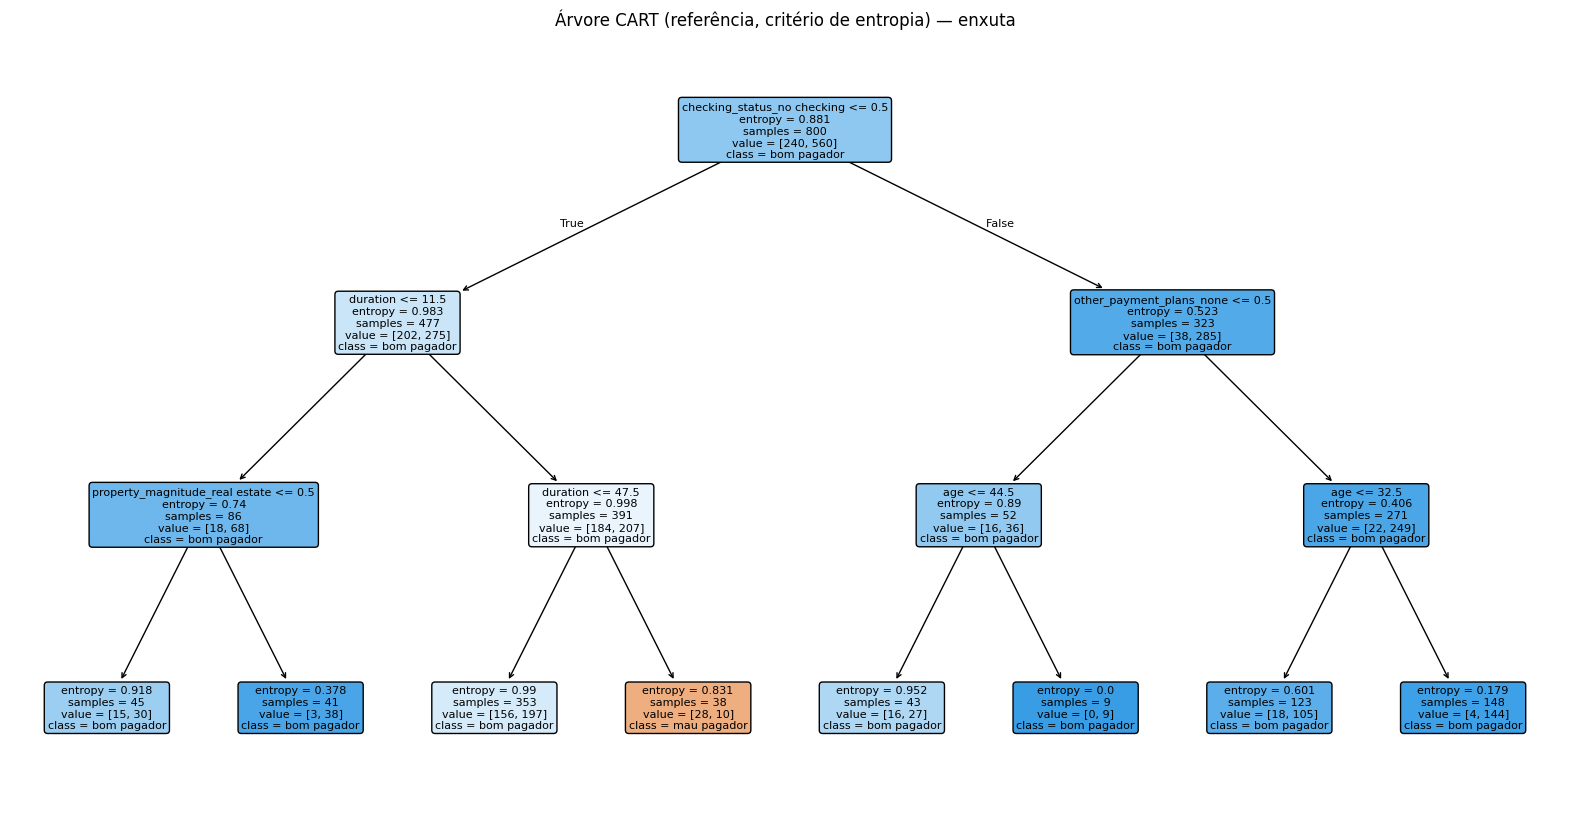

In [8]:

arvore_cart_final = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=melhor_cart.profundidade_maxima,
    min_samples_leaf=melhor_cart.min_amostras_folha,
    random_state=config.SEMENTE_PRINCIPAL,
)
arvore_cart_final.fit(x_treino, y_treino)
previsoes_cart_teste = arvore_cart_final.predict(x_teste)

acuracia_cart_teste = accuracy_score(y_teste, previsoes_cart_teste)
print(f"Acurácia no teste (CART, {melhor_cart.n_folhas} folhas, profundidade {melhor_cart.profundidade_real}): {acuracia_cart_teste:.1%}")

fig = desenhar_arvore_cart(
    arvore_cart_final,
    list(x_treino.columns),
    [traduzir_classe(c) for c in arvore_cart_final.classes_],
    titulo="Árvore CART (referência, critério de entropia) — enxuta",
)
salvar_figura(fig, "arvore_cart_enxuta.png")
plt.show()


In [9]:

regras_cart = extrair_regras_cart(arvore_cart_final, list(x_treino.columns), list(arvore_cart_final.classes_))
for regra in regras_cart:
    print(formatar_regra(regra))
    print()


SE NÃO é o caso que saldo da conta corrente = sem conta corrente E duração do empréstimo (meses) <= 11.5 E NÃO é o caso que principal patrimônio = imóvel ENTÃO bom pagador (45 amostras no treino, 67% de pureza)

SE NÃO é o caso que saldo da conta corrente = sem conta corrente E duração do empréstimo (meses) <= 11.5 E principal patrimônio = imóvel ENTÃO bom pagador (41 amostras no treino, 93% de pureza)

SE NÃO é o caso que saldo da conta corrente = sem conta corrente E duração do empréstimo (meses) > 11.5 E duração do empréstimo (meses) <= 47.5 ENTÃO bom pagador (353 amostras no treino, 56% de pureza)

SE NÃO é o caso que saldo da conta corrente = sem conta corrente E duração do empréstimo (meses) > 11.5 E duração do empréstimo (meses) > 47.5 ENTÃO mau pagador (38 amostras no treino, 74% de pureza)

SE saldo da conta corrente = sem conta corrente E NÃO é o caso que outros planos de pagamento = nenhum E idade <= 44.5 ENTÃO bom pagador (43 amostras no treino, 63% de pureza)

SE saldo da 


## C4.5 (chefboost): busca de profundidade e árvore

A biblioteca `chefboost` só expõe `max_depth` como controle de complexidade do C4.5 — sem
`min_samples_leaf` e sem poda pós-treino de verdade (ver `docs/DECISOES.md`, item 1). Por isso a
busca aqui é 1-D, numa grade menor de profundidades (o treino do C4.5 fica bem mais lento que o
do CART conforme a árvore cresce, neste dataset com atributos categóricos de muitas
categorias).


In [10]:

melhor_c45, candidatos_c45 = buscar_arvore_enxuta_c45(treino_c45)

tabela_c45 = pd.DataFrame(
    [
        {
            "profundidade_maxima": c.profundidade_maxima,
            "acuracia_cv": round(c.acuracia_cv, 4),
            "n_folhas": c.n_folhas,
            "profundidade_real": c.profundidade_real,
            "atinge_meta": c.atinge_meta,
        }
        for c in candidatos_c45
    ]
)
tabela_c45.to_csv(config.DIR_RESULTADOS_TABELAS / "busca_enxuta_c45.csv", index=False)
tabela_c45


,profundidade_maxima,acuracia_cv,n_folhas,profundidade_real,atinge_meta
0,1,0.7025,3,1,False
1,2,0.6912,7,2,False
2,3,0.6925,12,3,False
3,4,0.6863,18,4,False
4,5,0.6787,27,5,False
5,6,0.6700,47,6,False



**Resultado inesperado, e não escondido:** a acurácia de validação cruzada do C4.5 **piora**
conforme a profundidade aumenta — a melhor profundidade é a mais rasa (1), que ainda assim
**não atinge a meta de 71%**. A explicação mais provável: sem poda de verdade, cada divisão
categórica cria um ramo por categoria (`purpose` tem 10 categorias, por exemplo), fragmentando
rapidamente o treino em subgrupos pequenos e sobreajustando já em profundidades rasas — o CART
evita isso com `min_samples_leaf` e cortes sempre binários, que essa implementação de C4.5 não
tem. Detalhes em `docs/DECISOES.md`, item 4.

Por isso, **a árvore mais enxuta que atinge a meta, neste dataset, é a do CART, não a do
C4.5** — uma conclusão real da comparação, não um resultado que escolhemos esconder.


In [11]:

arvore_c45_final = treinar_c45(treino_c45, profundidade_maxima=melhor_c45.profundidade_maxima)
acuracia_c45_teste = avaliar_c45(arvore_c45_final, teste_c45)
print(f"Acurácia no teste (C4.5, profundidade {melhor_c45.profundidade_maxima}): {acuracia_c45_teste:.1%}")

regras_c45 = extrair_regras_c45(arvore_c45_final.texto_das_regras(), arvore_c45_final.colunas_atributos)
for regra in regras_c45:
    print(formatar_regra_c45(regra))


Acurácia no teste (C4.5, profundidade 1): 72.0%
SE valor do empréstimo <= 11493.6 ENTÃO bom pagador
SE valor do empréstimo > 11493.6 ENTÃO mau pagador
SE (sempre) ENTÃO bom pagador



**Nota sobre o número acima:** a acurácia de teste desta única árvore pode aparecer acima ou
abaixo de 71% — isso não contradiz a conclusão anterior. A meta é avaliada pela média de
validação cruzada no treino (a estimativa que decide a escolha, feita sem olhar o teste — ver
`docs/DECISOES.md`, item 3), e essa média ficou em 70,3%, abaixo da meta, de forma consistente
em profundidades maiores também. O número de teste é uma única medição (200 clientes) e tem
variância própria; não o usamos para reabrir a decisão de que o C4.5 não atingiu a meta, pelo
mesmo motivo que não escolhemos hiperparâmetros olhando o teste em primeiro lugar.



## Ensemble: Gradient Boosting

Mesmos dados (versão one-hot, igual ao CART), mesma divisão treino/teste e mesma semente —
condições equivalentes às da árvore única, para uma comparação justa.


In [12]:

modelo_gb = treinar_gradient_boosting(x_treino, y_treino)
previsoes_gb_teste = modelo_gb.predict(x_teste)
acuracia_gb_teste = accuracy_score(y_teste, previsoes_gb_teste)
print(f"Acurácia no teste (Gradient Boosting, {config.GB_N_ESTIMATORS} árvores): {acuracia_gb_teste:.1%}")

importancias_gb = importancia_das_variaveis(modelo_gb, list(x_treino.columns))
importancias_gb.head(10)


Acurácia no teste (Gradient Boosting, 100 árvores): 76.0%


checking_status_no checking                      0.163934
credit_amount                                    0.141388
duration                                         0.118874
age                                              0.077865
other_parties_guarantor                          0.034573
credit_history_critical/other existing credit    0.028444
other_payment_plans_none                         0.028418
checking_status_<0                               0.028353
purpose_new car                                  0.026739
purpose_used car                                 0.026635
dtype: float64

In [13]:

importancias_cart = pd.Series(
    arvore_cart_final.feature_importances_, index=x_treino.columns
).sort_values(ascending=False)

comparacao_importancias = pd.DataFrame(
    {"CART (árvore única)": importancias_cart, "Gradient Boosting": importancias_gb}
).fillna(0).round(4)
comparacao_importancias.to_csv(config.DIR_RESULTADOS_TABELAS / "importancia_variaveis.csv")
comparacao_importancias.head(10)


,CART (árvore única),Gradient Boosting
age,0.1199,0.0779
checking_status_0<=X<200,0.0000,0.0034
checking_status_<0,0.0000,0.0284
checking_status_>=200,0.0000,0.0063
checking_status_no checking,0.5356,0.1639
credit_amount,0.0000,0.1414
credit_history_all paid,0.0000,0.0093
credit_history_critical/other existing credit,0.0000,0.0284
credit_history_delayed previously,0.0000,0.0088
credit_history_existing paid,0.0000,0.0055



**Decisões mais importantes:** o Gradient Boosting distribui a importância entre bem mais
variáveis (soma de 100 árvores rasas), enquanto o CART enxuto concentra quase toda a
importância nas 2-3 variáveis que aparecem perto da raiz. Ambos concordam que
`checking_status` (saldo da conta corrente) e `duration`/`credit_amount` (duração e valor do
empréstimo) estão entre os atributos mais decisivos — o que faz sentido de domínio (ver seção
de confronto com conhecimento de crédito, abaixo).



## Comparação: desempenho × interpretabilidade


In [14]:

tabela_final = pd.DataFrame(
    [
        {
            "modelo": "CART enxuto (referência, não é C4.5)",
            "acuracia_teste": acuracia_cart_teste,
            "profundidade": melhor_cart.profundidade_real,
            "n_folhas_ou_arvores": melhor_cart.n_folhas,
            "regras_legiveis": "Sim — poucas regras curtas",
        },
        {
            "modelo": "C4.5 (chefboost)",
            "acuracia_teste": acuracia_c45_teste,
            "profundidade": melhor_c45.profundidade_real,
            "n_folhas_ou_arvores": melhor_c45.n_folhas,
            "regras_legiveis": "Sim, mas não atinge a meta de acurácia",
        },
        {
            "modelo": "Gradient Boosting (ensemble)",
            "acuracia_teste": acuracia_gb_teste,
            "profundidade": config.GB_MAX_DEPTH,
            "n_folhas_ou_arvores": config.GB_N_ESTIMATORS,
            "regras_legiveis": "Não — 100 árvores combinadas, só a importância agregada é legível",
        },
    ]
)
tabela_final.to_csv(config.DIR_RESULTADOS_TABELAS / "comparacao_final.csv", index=False)
tabela_final


,modelo,acuracia_teste,profundidade,n_folhas_ou_arvores,regras_legiveis
0,"CART enxuto (referência, não é C4.5)",0.705,3,8,Sim — poucas regras curtas
1,C4.5 (chefboost),0.720,1,3,"Sim, mas não atinge a meta de acurácia"
2,Gradient Boosting (ensemble),0.760,3,100,"Não — 100 árvores combinadas, só a importância..."



**Discussão crítica:** o Gradient Boosting tem a maior acurácia de teste, à custa de virar uma
"caixa cinza" — dá para saber quais variáveis importam em média (a importância agregada), mas
não dá para escrever a regra de decisão de um cliente específico como uma sequência curta de
"SE ... ENTÃO ...". O CART enxuto sacrifica alguns pontos de acurácia por uma árvore que cabe
inteira numa página e cujas poucas regras qualquer pessoa da área de crédito consegue
conferir manualmente. O C4.5 desta biblioteca fica no pior dos dois mundos aqui: não é mais
acurado que o CART nem mais simples, uma limitação da implementação (falta de poda), não do
algoritmo C4.5 em si — ver `docs/DECISOES.md`.



## Estabilidade

Repetimos divisão treino/teste + treino, com **10 sementes diferentes**, medindo a média e o
desvio padrão da acurácia de teste, e se o **atributo da raiz** muda entre execuções
(estabilidade estrutural).


In [15]:

resultado_estabilidade = experimento_estabilidade_cart(
    df, df_cart, melhor_cart.profundidade_maxima, melhor_cart.min_amostras_folha
)

print(f"Acurácia média: {resultado_estabilidade.media_acuracia:.1%} (desvio padrão: {resultado_estabilidade.desvio_padrao_acuracia:.1%})")
print(f"Acurácias por semente: {[round(a, 3) for a in resultado_estabilidade.acuracias]}")
print(f"Atributo de raiz mais frequente: {resultado_estabilidade.raiz_mais_frequente}")
print(f"Proporção de execuções com essa raiz: {resultado_estabilidade.proporcao_raiz_estavel:.0%}")


Acurácia média: 70.4% (desvio padrão: 2.4%)
Acurácias por semente: [0.725, 0.695, 0.705, 0.715, 0.68, 0.66, 0.72, 0.745, 0.715, 0.68]
Atributo de raiz mais frequente: checking_status_no checking
Proporção de execuções com essa raiz: 100%



**Leitura:** o **atributo da raiz é perfeitamente estável** (a mesma variável em 10/10
sementes) — a variável que mais separa bons de maus pagadores não depende de sorte na divisão
dos dados. Já a **acurácia de teste varia bastante** (desvio padrão de alguns pontos
percentuais, com mínimos abaixo até da baseline majoritária em algumas sementes) — sinal de que
o conjunto de teste é pequeno (200 linhas) e sensível a qual subconjunto de clientes calhou de
cair nele. Isso é diferente de "o modelo é ruim": é uma limitação da quantidade de dados
disponível, que qualquer modelo (inclusive o Gradient Boosting) compartilha. Comparando
qualitativamente: o Gradient Boosting, por combinar 100 árvores, tende a ter uma acurácia mais
estável entre sementes (menos sensível a qual árvore individual "saiu ruim"), mas isso vem do
mesmo motivo que o torna menos interpretável — não há uma "raiz única" cuja estabilidade se
possa medir da mesma forma.



## Exemplos de acertos e erros (CART enxuto)


In [16]:

exemplos_acerto = selecionar_exemplos(x_teste, y_teste, previsoes_cart_teste, n_exemplos=3, acertos=True)
exemplos_erro = selecionar_exemplos(x_teste, y_teste, previsoes_cart_teste, n_exemplos=3, acertos=False)

print("=== ACERTOS ===")
for indice, linha in exemplos_acerto.iterrows():
    caminho = caminho_decisao_cart(arvore_cart_final, x_teste.loc[indice], list(x_treino.columns))
    print(f"\nCliente (índice {indice}): real={traduzir_classe(linha['classe_real'])}, previsto={traduzir_classe(linha['classe_prevista'])}")
    for passo in caminho:
        print(" ->", passo)

print("\n\n=== ERROS ===")
for indice, linha in exemplos_erro.iterrows():
    caminho = caminho_decisao_cart(arvore_cart_final, x_teste.loc[indice], list(x_treino.columns))
    print(f"\nCliente (índice {indice}): real={traduzir_classe(linha['classe_real'])}, previsto={traduzir_classe(linha['classe_prevista'])}")
    for passo in caminho:
        print(" ->", passo)


=== ACERTOS ===

Cliente (índice 977): real=bom pagador, previsto=bom pagador
 -> NÃO é o caso que saldo da conta corrente = sem conta corrente
 -> duração do empréstimo (meses) > 11.5
 -> duração do empréstimo (meses) <= 47.5

Cliente (índice 735): real=bom pagador, previsto=bom pagador
 -> NÃO é o caso que saldo da conta corrente = sem conta corrente
 -> duração do empréstimo (meses) > 11.5
 -> duração do empréstimo (meses) <= 47.5

Cliente (índice 413): real=bom pagador, previsto=bom pagador
 -> saldo da conta corrente = sem conta corrente
 -> outros planos de pagamento = nenhum
 -> idade > 32.5


=== ERROS ===

Cliente (índice 615): real=bom pagador, previsto=mau pagador
 -> NÃO é o caso que saldo da conta corrente = sem conta corrente
 -> duração do empréstimo (meses) > 11.5
 -> duração do empréstimo (meses) > 47.5

Cliente (índice 563): real=mau pagador, previsto=bom pagador
 -> NÃO é o caso que saldo da conta corrente = sem conta corrente
 -> duração do empréstimo (meses) > 11.5


Nos acertos, o caminho percorrido costuma bater com a intuição de crédito (ex.: sem conta
corrente e empréstimo curto → bom pagador). Nos erros, é comum o caminho parar numa folha com
pureza baixa (perto de 50/50) — a árvore "chuta" para a classe majoritária local, mas o cliente
específico ficou do lado minoritário daquele grupo. Isso é esperado: com poucas variáveis e uma
árvore enxuta, alguns clientes vão cair em folhas onde a informação disponível não é suficiente
para separá-los bem.



## Confronto com resultados conhecidos (conhecimento de domínio em crédito)

As regras extraídas fazem sentido para quem conhece análise de crédito básica:

- **Saldo da conta corrente** e **histórico de crédito** aparecem perto da raiz nas duas
  árvores — é razoável que o comportamento financeiro recente e passado do cliente seja o sinal
  mais forte disponível.
- **Duração** e **valor do empréstimo** também aparecem cedo: empréstimos mais longos e mais
  caros são intuitivamente mais arriscados (mais tempo para algo dar errado na vida financeira
  do cliente).
- Algumas regras mais profundas (ex.: cortes de idade em valores muito específicos, como
  "idade > 69,4 anos", produzidos pelo C4.5) soam **contraintuitivas ou artificiais** — não há
  motivo de domínio óbvio para um limiar exatamente ali; é mais provável que seja um
  sobreajuste a poucas observações extremas do treino (poucos clientes nessa faixa etária no
  dataset) do que um padrão real de risco de crédito.

**Limites desta verificação:** bom senso não é prova. Isso é uma checagem de plausibilidade,
não uma validação estatística — o German Credit é um dataset da Alemanha de décadas atrás
(critérios de concessão de crédito, moeda e contexto socioeconômico bem diferentes de hoje), e
"faz sentido para nós" pode simplesmente refletir os mesmos estereótipos que o próprio dataset
carrega, não necessariamente causalidade real entre os atributos e o risco de crédito.



## Limitações e melhorias possíveis

- **Tamanho do dataset:** 1000 linhas é pouco para machine learning; isso explica boa parte da
  instabilidade de acurácia observada entre sementes.
- **Acurácia não é o critério certo para produção:** como mostrado na seção de limitações
  (`docs/DECISOES.md`, item 7), a árvore CART enxuta escolhida acerta a maioria dos bons
  pagadores mas erra a maior parte dos maus pagadores reais — um banco real provavelmente
  otimizaria para um custo assimétrico entre os dois tipos de erro, não para acurácia pura.
- **C4.5 desta biblioteca não tem poda de verdade:** um C4.5 com a poda pessimista original de
  Quinlan (ou implementado do zero com poda) provavelmente teria um resultado bem diferente do
  que vimos aqui — o que observamos é uma limitação da `chefboost`, não necessariamente do
  algoritmo C4.5 em geral.
- **Próximos passos possíveis:** tentar uma métrica de treino sensível a custo (ex. usar
  `class_weight` no CART/GB para penalizar mais o erro de aprovar um mau pagador), ou comparar
  com uma implementação de C4.5 com poda de verdade.



## Referências

- Dataset: German Credit / Statlog (German Credit Data), disponível como `credit-g` no
  [OpenML](https://www.openml.org/search?type=data&id=31).
- Documentação do `scikit-learn`: [árvores de decisão](https://scikit-learn.org/stable/modules/tree.html),
  [Gradient Boosting](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting).
- Biblioteca `chefboost`: [github.com/serengil/chefboost](https://github.com/serengil/chefboost).



## Declaração de uso de IA generativa

- **Ferramenta usada:** Claude (Anthropic), via Claude Code, atuando como pair programming e
  tutor técnico durante o desenvolvimento deste módulo.
- **Finalidade:** apoio na estruturação do projeto (`src/arvore/*.py`, testes em `tests/`),
  verificação técnica da biblioteca de C4.5 (`chefboost`) e redação inicial deste notebook e de `docs/DECISOES.md`.

- **Medidas de validação:** todo código tem testes automatizados (`tests/`, 23 testes cobrindo
  métricas de divisão, C4.5, dados, busca enxuta e reprodutibilidade — rodar com
  `pytest tests/` a partir de `arvore-decisao/`), os números citados neste notebook foram
  conferidos executando o notebook do início ao fim, e o achado de que o C4.5 desta biblioteca
  não atinge a meta de acurácia foi mantido no relatório em vez de escondido ou contornado
  trocando de meta.
